<a href="https://colab.research.google.com/github/Jigyasa-sharma7/Pollution-Level-Forecasting/blob/main/notebooks/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("/content/pollution_model_data.csv")

In [20]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [21]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (412028, 19)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime']


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412028 entries, 0 to 412027
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   No        412028 non-null  int64  
 1   year      412028 non-null  int64  
 2   month     412028 non-null  int64  
 3   day       412028 non-null  int64  
 4   hour      412028 non-null  int64  
 5   PM2.5     412028 non-null  float64
 6   PM10      412028 non-null  float64
 7   SO2       412028 non-null  float64
 8   NO2       412028 non-null  float64
 9   CO        412028 non-null  float64
 10  O3        412028 non-null  float64
 11  TEMP      412028 non-null  float64
 12  PRES      412028 non-null  float64
 13  DEWP      412028 non-null  float64
 14  RAIN      412028 non-null  float64
 15  wd        412028 non-null  object 
 16  WSPM      412028 non-null  float64
 17  station   412028 non-null  object 
 18  datetime  412028 non-null  object 
dtypes: float64(11), int64(5), object(3)
memory u

One thing we'll need to remember: when loading from CSV, datetime will initially become an object/string again.

So we'll convert it back:

In [25]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [26]:
print(df["datetime"].dtype)

datetime64[ns]


First EDA step: Basic statistics

In [27]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028.000000,412028
mean,17519.734215,2014.661557,6.517402,15.731640,11.489348,79.791197,104.807664,15.865820,50.669985,1235.163133,56.921073,13.485027,1010.784419,2.452197,0.063957,1.727103,2015-02-28 22:44:03.172793856
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8730.000000,2014.000000,4.000000,8.000000,5.000000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-9.000000,0.000000,0.900000,2014-02-27 17:00:00
50%,17523.000000,2015.000000,7.000000,16.000000,11.000000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.400000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 02:00:00
75%,26283.000000,2016.000000,10.000000,23.000000,18.000000,111.000000,145.000000,20.000000,71.000000,1500.000000,81.000000,23.200000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 02:00:00
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,957.000000,995.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,10132.929132,1.178980,3.452462,8.796408,6.933320,80.809802,92.228296,21.813108,35.184018,1161.304176,56.975770,11.437085,10.468293,13.806305,0.817761,1.245397,NaN


In [28]:
df["PM2.5"].describe()

,PM2.5
count,412028.000000
mean,79.791197
std,80.809802
min,2.000000
25%,20.000000
50%,55.000000
75%,111.000000
max,957.000000


## 1. PM2.5 Distribution

We first examine the distribution of PM2.5 concentrations to understand the typical pollution levels, variability, skewness, and presence of extreme values.

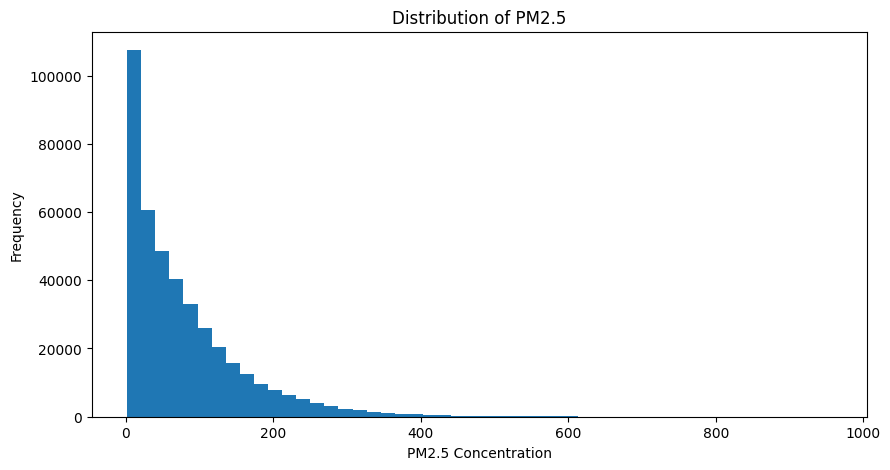

In [29]:
plt.figure(figsize=(10, 5))

plt.hist(df["PM2.5"], bins=50)

plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5")

plt.show()

### Observation

The PM2.5 distribution is strongly right-skewed (positively skewed). Most observations have relatively low to moderate PM2.5 concentrations, while a smaller number of observations have very high concentrations. The long right tail indicates the presence of extreme pollution episodes.

The mean PM2.5 concentration (79.79) is higher than the median (55), which further supports the positive skewness of the distribution.

The maximum PM2.5 value is 957, indicating substantial variation in pollution levels across time and monitoring stations.

## 2. PM2.5 Boxplot

A boxplot is used to examine the spread of PM2.5 values and identify potential outliers.

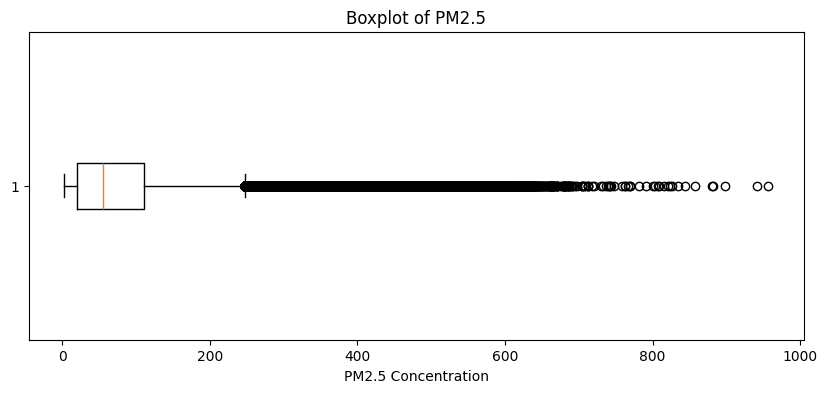

In [30]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["PM2.5"], vert=False)

plt.xlabel("PM2.5 Concentration")
plt.title("Boxplot of PM2.5")

plt.show()

### Observation

The boxplot shows that PM2.5 has a strong right-skewed distribution with a large number of observations beyond the upper whisker. These observations represent unusually high PM2.5 concentrations.

The median PM2.5 concentration is approximately 55, while the middle 50% of observations lie roughly between 20 and 111. The presence of many high-value observations is consistent with the right-skewed distribution observed in the histogram.

These extreme values are not removed because they may represent genuine high-pollution episodes rather than data errors. Therefore, they are retained for further analysis and modeling.

## 3. PM2.5 Levels by Monitoring Station

The dataset contains observations from 12 monitoring stations. We compare the average PM2.5 concentration across stations to identify differences in pollution levels between locations.

In [31]:
station_pm25 = (
    df.groupby("station")["PM2.5"]
      .mean()
      .sort_values(ascending=False)
)

print(station_pm25)

station
Dongsi           86.194297
Wanshouxigong    84.997541
Nongzhanguan     84.838483
Gucheng          83.852089
Wanliu           83.374716
Guanyuan         82.933372
Aotizhongxin     82.773611
Tiantan          82.164911
Shunyi           79.491602
Changping        71.099743
Huairou          69.626367
Dingling         65.989497
Name: PM2.5, dtype: float64


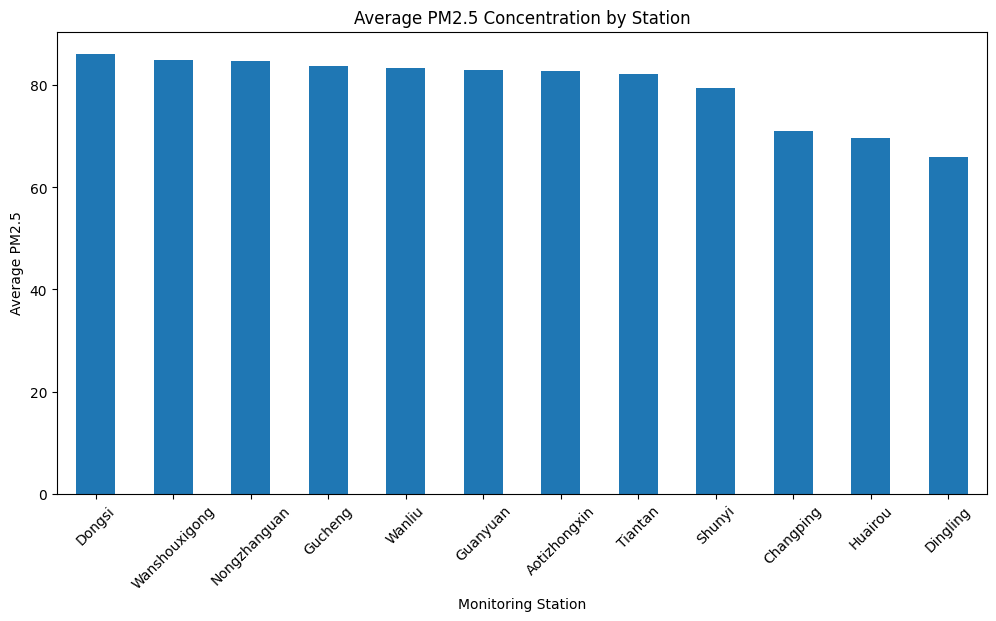

In [32]:
plt.figure(figsize=(12, 6))

station_pm25.plot(kind="bar")

plt.xlabel("Monitoring Station")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 Concentration by Station")
plt.xticks(rotation=45)

plt.show()

### Observation

The average PM2.5 concentration varies across the 12 monitoring stations.

Dongsi has the highest average PM2.5 concentration, while Dingling has the lowest. Several stations such as Wanshouxigong and Nongzhanguan also show relatively high average PM2.5 levels.

This variation indicates that pollution levels differ by location. Therefore, the monitoring station is an important feature and will be retained for the machine learning model.

## 4. PM2.5 Variation by Hour

Air pollution can vary throughout the day because of changes in traffic, atmospheric conditions, human activity, and pollutant dispersion.

We examine the average PM2.5 concentration for each hour of the day.

In [33]:
hourly_pm25 = (
    df.groupby("hour")["PM2.5"]
      .mean()
)

print(hourly_pm25)

hour
0     87.588425
1     86.559755
2     84.463228
3     82.014665
4     79.299768
5     76.395365
6     74.240960
7     73.272242
8     74.533339
9     76.059757
10    77.122795
11    77.351682
12    76.858321
13    76.220075
14    75.326829
15    74.523816
16    74.099249
17    75.367208
18    78.022090
19    82.497017
20    86.555549
21    88.780560
22    88.887939
23    88.606751
Name: PM2.5, dtype: float64


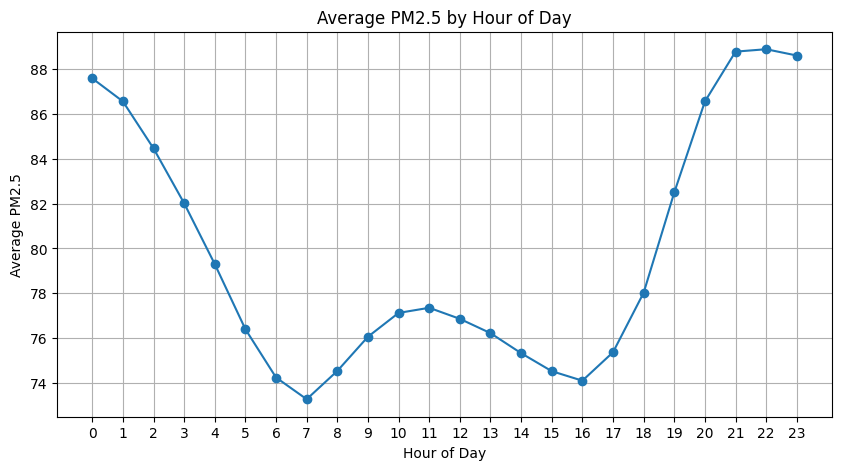

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_pm25.index, hourly_pm25.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 by Hour of Day")
plt.xticks(range(24))

plt.grid(True)
plt.show()

### Observation

The average PM2.5 concentration varies considerably throughout the day.

PM2.5 levels are relatively high during the late evening and nighttime, reaching the highest average value of approximately 88.89 at 22:00. The lowest average value is approximately 73.27 at 07:00.

The variation in PM2.5 concentration across different hours suggests that time of day may be an important factor in predicting pollution levels.

However, the hourly pattern may also be influenced by other factors such as weather conditions, wind speed, temperature, and atmospheric pressure, which will be examined in later stages of the EDA.